# Diffusion models, the smallest working example

### Destroy the data with noise, learn to undo one step, then undo them all

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The forward noising schedule and the reverse step written from scratch, what a diffusion model actually predicts, how sample quality trades against the number of denoising steps, and whether diffusion really covers modes better than the GAN from [10-03](../03-generative-adversarial-networks/) on the same ring |
| **You should already know** | [10-03 Generative adversarial networks](../03-generative-adversarial-networks/), whose ring of eight Gaussians and coverage metric are reused here unchanged |
| **Dataset** | The same 2-D mixture of eight Gaussians as 10-03 for everything measured; Fashion-MNIST (12,000 images, the same subsample as 10-01 to 10-03) for the closing demonstration |
| **Runtime** | Three to five minutes on a laptop CPU. The device it used is printed below |
| **Next** | [11-01 The reinforcement learning setup](../../11-reinforcement-learning/01-the-rl-setup/) |

---

## 1. The idea

Take a picture and add a little noise. Add a little more. Keep going, a few
hundred times, until nothing is left but static. That direction is easy: it is
arithmetic, it has no parameters, and you can jump to any point along it in one
line.

Now run it backwards. If you knew, for a slightly noisy image, exactly what
noise had been added, you could subtract it and get a slightly cleaner image.
Repeat that a few hundred times starting from pure static and you have generated
a picture. That is the whole method. The network's only job is to look at a noisy
sample, be told how noisy it is, and say what the noise was.

Compare that with what [10-03](../03-generative-adversarial-networks/) had to do.
A GAN learns a generator by playing it against a discriminator that is learning
at the same time, with no fixed objective and no reliable progress signal. A
diffusion model has a fixed target at every step, a plain regression loss, and no
opponent. It buys that stability with sampling cost: one forward pass per
denoising step, hundreds of them, against the GAN's single pass. Section 4
measures that trade directly.

The claim I most want to test is the one people repeat about mode coverage. A
GAN can collapse onto a subset of the data and its loss will not complain.
Diffusion is said not to do that. Section 5 runs both on the same ring of eight
Gaussians, with the same coverage metric, and reports what happened.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

T = 200                # denoising steps in the full chain
N_EVAL = 2000          # points drawn whenever coverage is measured
SEEDS = [0, 1, 2]      # both families are trained at three seeds

NOTEBOOK_STARTED = time.perf_counter()
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


### The ring, copied from 10-03 without changes

Eight Gaussians spaced around a circle, and the two measurements defined in the
GAN chapter. **Coverage** is how many modes the generator reaches, where a point
lands on a mode if it falls within three standard deviations of that centre and
a mode counts as covered if at least one per cent of the batch lands on it.
**Quality** is the share of points that land on any mode at all.

I add one more, because coverage saturates on this problem and stops
discriminating. **Imbalance** is the total variation distance between the
per-mode shares and a uniform eight-way split. Real data scores near zero,
limited only by sampling noise, and a generator that reaches every mode but
spends most of its mass on two of them scores high.

In [2]:
N_MODES = 8
RADIUS = 2.0
SPREAD = 0.10

_angles = 2 * np.pi * np.arange(N_MODES) / N_MODES
CENTRES = np.stack([RADIUS * np.cos(_angles), RADIUS * np.sin(_angles)], axis=1)


def sample_ring(n, rng):
    """n draws from an equal mixture of the eight Gaussians."""
    which = rng.integers(0, N_MODES, size=n)
    return (CENTRES[which] + SPREAD * rng.standard_normal((n, 2))).astype(np.float32)


def mode_stats(points, tol=3.0, min_share=0.01):
    """Coverage, quality and per-mode counts, exactly as defined in 10-03."""
    distances = np.linalg.norm(points[:, None, :] - CENTRES[None, :, :], axis=2)
    nearest, closest = distances.argmin(axis=1), distances.min(axis=1)
    on_mode = closest < tol * SPREAD
    counts = np.bincount(nearest[on_mode], minlength=N_MODES)
    return {"covered": int((counts >= min_share * len(points)).sum()),
            "quality": float(on_mode.mean()),
            "counts": counts}


def imbalance(counts):
    """Total variation distance between the per-mode shares and a uniform split."""
    total = counts.sum()
    if total == 0:
        return 1.0
    return float(0.5 * np.abs(counts / total - 1.0 / N_MODES).sum())


rng = np.random.default_rng(SEED)
real_cloud = sample_ring(N_EVAL, rng)
real_stats = mode_stats(real_cloud)

print(f"real data: {real_stats['covered']} of {N_MODES} modes, "
      f"quality {real_stats['quality']:.3f}, imbalance {imbalance(real_stats['counts']):.4f}")
print(f"per-mode shares: {np.round(real_stats['counts'] / N_EVAL, 3)}")
print("The imbalance of real data is the floor. Nothing can do better than sampling noise.")

real data: 8 of 8 modes, quality 0.994, imbalance 0.0222
per-mode shares: [0.11  0.118 0.122 0.125 0.131 0.126 0.13  0.13 ]
The imbalance of real data is the floor. Nothing can do better than sampling noise.


## 2. The maths

### Forward, and the shortcut that makes it trainable

One noising step multiplies the sample down a little and adds Gaussian noise:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\left(\sqrt{1 - \beta_t}\, x_{t-1},\ \beta_t I\right)$$

The $\sqrt{1-\beta_t}$ is there so the variance stays near one instead of growing
without bound. Chaining $t$ of these is another Gaussian, and writing
$\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s \le t}\alpha_s$ it comes out as

$$q(x_t \mid x_0) = \mathcal{N}\left(\sqrt{\bar\alpha_t}\, x_0,\ (1 - \bar\alpha_t) I\right)
  \qquad\text{so}\qquad
  x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon$$

That single line is what makes training cheap. To make a training example at
step 137 you do not simulate 137 steps; you draw one $\varepsilon$ and evaluate
the formula.

### What the network predicts

The reverse of a small Gaussian step is itself close to Gaussian, so a model only
has to supply its mean. After the algebra in the DDPM paper, that mean is a known
function of $x_t$ and the noise $\varepsilon$ that produced it. So the network is
trained to output $\varepsilon$, and the loss is the plainest thing in this book:

$$\mathcal{L} = \mathbb{E}_{x_0,\, t,\, \varepsilon}
  \left\| \varepsilon - \varepsilon_\theta\!\left(\sqrt{\bar\alpha_t} x_0
  + \sqrt{1-\bar\alpha_t}\,\varepsilon,\ t\right) \right\|^2$$

A mean squared error against a target you generated yourself. There is no
adversary, no balance to maintain, and the loss falling means the model is
getting better at the thing it will be asked to do at sampling time. Section 3
checks that last claim against measured sample quality, because
[10-03](../03-generative-adversarial-networks/) found the GAN's loss had no such
relationship.

### One reverse step

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}
  \left(x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\, \varepsilon_\theta(x_t, t)\right)
  + \sigma_t z, \qquad z \sim \mathcal{N}(0, I)$$

Subtract the predicted noise, rescale, add a little fresh noise back except on
the last step. That is the sampler.

## 3. From scratch, on points

### The schedule

In [3]:
betas = torch.linspace(1e-4, 0.05, T)
alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

betas_d, alphas_d, alphas_bar_d = betas.to(device), alphas.to(device), alphas_bar.to(device)

schedule_table = pd.DataFrame({
    "t": [0, T // 8, T // 4, T // 2, 3 * T // 4, T - 1],
})
schedule_table["beta"] = [float(betas[t]) for t in schedule_table["t"]]
schedule_table["alpha bar"] = [float(alphas_bar[t]) for t in schedule_table["t"]]
schedule_table["signal kept"] = np.sqrt(schedule_table["alpha bar"])
schedule_table["noise added"] = np.sqrt(1 - schedule_table["alpha bar"])

print(schedule_table.to_string(index=False, float_format="{:.4f}".format))
print(f"\nat the end of the chain the data contributes "
      f"{float(np.sqrt(alphas_bar[-1])):.4f} of the signal")

noisiest = np.sqrt(float(alphas_bar[-1])) * real_cloud + np.sqrt(1 - float(alphas_bar[-1])) \
    * rng.standard_normal(real_cloud.shape)
print(f"standard deviation of x_T: {noisiest.std():.3f}, against 1.000 for the "
      f"pure Gaussian the sampler starts from")

  t   beta  alpha bar  signal kept  noise added
  0 0.0001     0.9999       0.9999       0.0100
 25 0.0064     0.9192       0.9587       0.2843
 50 0.0126     0.7217       0.8495       0.5276
100 0.0252     0.2760       0.5254       0.8509
150 0.0377     0.0555       0.2356       0.9719
199 0.0500     0.0061       0.0782       0.9969



at the end of the chain the data contributes 0.0782 of the signal
standard deviation of x_T: 1.008, against 1.000 for the pure Gaussian the sampler starts from


C:\Users\pilot\AppData\Local\Temp\ipykernel_31964\1210056475.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  f"{float(np.sqrt(alphas_bar[-1])):.4f} of the signal")


C:\Users\pilot\AppData\Local\Temp\ipykernel_31964\2030435795.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  f"{float(np.sqrt(alphas_bar[-1])):.3f} of the signal remains at step {T - 1}",


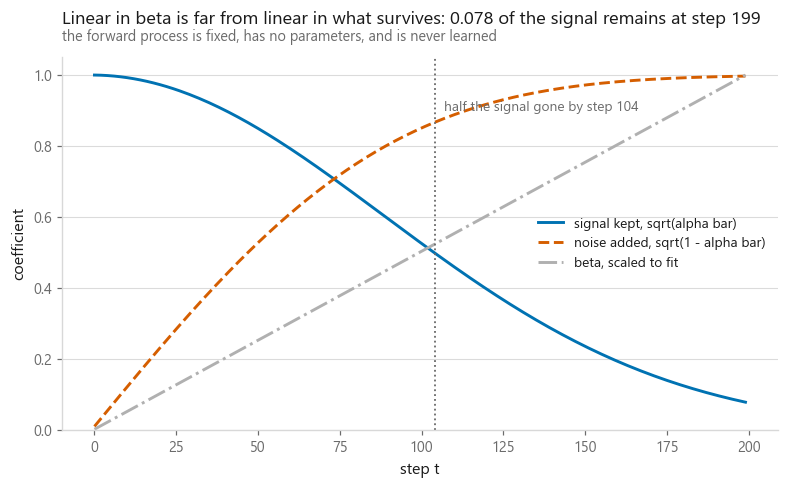

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
steps = np.arange(T)
ax.plot(steps, np.sqrt(alphas_bar.numpy()), color=style.PALETTE[0],
        ls=style.DASHES[0], label="signal kept, sqrt(alpha bar)")
ax.plot(steps, np.sqrt(1 - alphas_bar.numpy()), color=style.HIGHLIGHT,
        ls=style.DASHES[1], label="noise added, sqrt(1 - alpha bar)")
ax.plot(steps, betas.numpy() / betas.max().item(), color=style.NEUTRAL,
        ls=style.DASHES[2], label="beta, scaled to fit")

half = int(np.argmin(np.abs(np.sqrt(alphas_bar.numpy()) - 0.5)))
ax.axvline(half, color=style.MUTED, ls=":", lw=1.2)
ax.annotate(f"half the signal gone by step {half}", xy=(half, 0.9), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color=style.MUTED)

ax.set_xlabel("step t")
ax.set_ylabel("coefficient")
ax.set_ylim(0, 1.05)
ax.legend(loc="center right", fontsize=9)
style.title(ax, f"Linear in beta is far from linear in what survives: "
                f"{float(np.sqrt(alphas_bar[-1])):.3f} of the signal remains at step {T - 1}",
            "the forward process is fixed, has no parameters, and is never learned")
style.save(fig, FIG / "fig-01-schedule.png")

### The forward process, applied to the ring

C:\Users\pilot\AppData\Local\Temp\ipykernel_31964\4112930326.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  keep, add = float(np.sqrt(alphas_bar[t])), float(np.sqrt(1 - alphas_bar[t]))


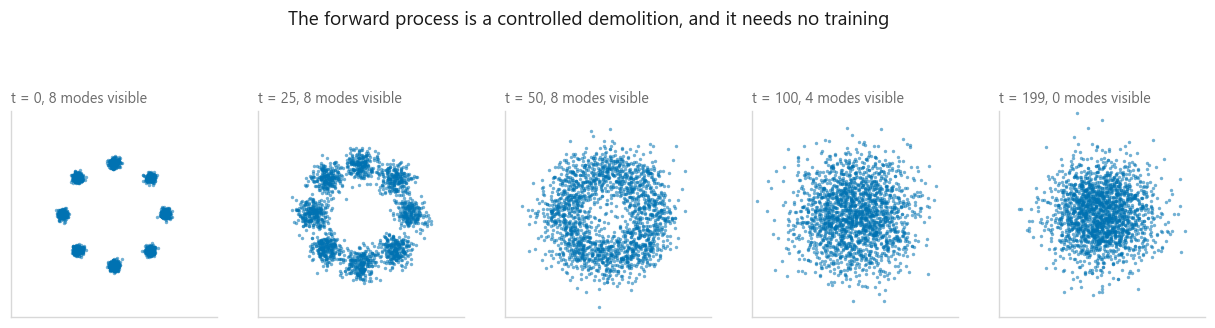

In [5]:
FORWARD_SHOW = [0, T // 8, T // 4, T // 2, T - 1]

fig, axes = plt.subplots(1, len(FORWARD_SHOW), figsize=(14.0, 3.4))
forward_rng = np.random.default_rng(SEED)
for ax, t in zip(axes, FORWARD_SHOW):
    keep, add = float(np.sqrt(alphas_bar[t])), float(np.sqrt(1 - alphas_bar[t]))
    noisy = keep * real_cloud + add * forward_rng.standard_normal(real_cloud.shape)
    stats = mode_stats(noisy.astype(np.float32))
    ax.scatter(noisy[:, 0], noisy[:, 1], s=5, linewidths=0, color=style.PALETTE[0], alpha=0.55)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t}, {stats['covered']} modes visible", fontsize=9.5,
                 color=style.MUTED, loc="left")

fig.suptitle("The forward process is a controlled demolition, and it needs no training",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-forward-noising.png")

### The network

Two coordinates and a step number in, two coordinates of predicted noise out.
The step number is turned into a vector of sines and cosines at different
frequencies, the same encoding the Transformer uses for position, because
feeding a raw integer into a linear layer gives the network almost nothing to
work with.

In [6]:
TIME_DIM = 32


def timestep_embedding(t, dim=TIME_DIM):
    """Sinusoids at geometrically spaced frequencies, so nearby steps look similar."""
    half = dim // 2
    frequencies = torch.exp(-np.log(10000.0) * torch.arange(half, device=t.device) / half)
    angles = t.float()[:, None] * frequencies[None, :]
    return torch.cat([torch.cos(angles), torch.sin(angles)], dim=-1)


class PointDenoiser(nn.Module):
    """Predict the noise that was added to a 2-D point at step t."""

    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + TIME_DIM, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, 2),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, timestep_embedding(t)], dim=-1))


print(f"{sum(p.numel() for p in PointDenoiser().parameters()):,} parameters, "
      f"predicting 2 numbers from 2 coordinates and a step index")

37,762 parameters, predicting 2 numbers from 2 coordinates and a step index


### Training, and the two samplers

Training is four lines: pick a random step for each point in the batch, noise the
point according to the closed form, ask the network for the noise, compare.

Two samplers follow. The first is the ancestral one from the maths above, which
walks every step and injects fresh noise on the way. The second walks a
subsequence of the steps and injects none, which is the DDIM sampler, and it is
how the number of denoising steps becomes a dial you can turn.

In [7]:
def train_points(seed, steps=4000, batch=512, lr=2e-3, checkpoints=()):
    """Train a point denoiser. Optionally measure sample quality along the way."""
    torch.manual_seed(seed)
    data_rng = np.random.default_rng(seed)
    model = PointDenoiser().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    history, started = [], time.perf_counter()
    recent = []
    for step in range(1, steps + 1):
        x0 = torch.from_numpy(sample_ring(batch, data_rng)).to(device)
        t = torch.randint(0, T, (batch,), device=device)
        noise = torch.randn_like(x0)

        keep = alphas_bar_d[t].sqrt()[:, None]
        add = (1 - alphas_bar_d[t]).sqrt()[:, None]
        noisy = keep * x0 + add * noise

        optimiser.zero_grad(set_to_none=True)
        loss = F.mse_loss(model(noisy, t), noise)
        loss.backward()
        optimiser.step()
        recent.append(float(loss))

        if step in checkpoints:
            cloud = sample_ddim(model, 1000, 25, seed=99)
            stats = mode_stats(cloud)
            history.append({"step": step, "loss": float(np.mean(recent)),
                            "covered": stats["covered"], "quality": stats["quality"]})
            recent = []
    return model, pd.DataFrame(history), time.perf_counter() - started


@torch.no_grad()
def sample_ddpm(model, n, seed=0, record=()):
    """The ancestral sampler: every step, with fresh noise injected on the way."""
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=generator).to(device)
    snapshots = {T: x.cpu().numpy()}

    for t in reversed(range(T)):
        index = torch.full((n,), t, device=device, dtype=torch.long)
        predicted = model(x, index)
        mean = (x - betas_d[t] / (1 - alphas_bar_d[t]).sqrt() * predicted) / alphas_d[t].sqrt()
        if t > 0:
            x = mean + betas_d[t].sqrt() * torch.randn(x.shape, generator=generator).to(device)
        else:
            x = mean
        if t in record:
            snapshots[t] = x.cpu().numpy()

    model.train()
    return x.cpu().numpy(), snapshots


@torch.no_grad()
def sample_ddim(model, n, steps, seed=0):
    """A subsequence of the chain, taken deterministically. `steps` is the dial."""
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=generator).to(device)
    walk = np.linspace(0, T - 1, steps).round().astype(int)[::-1]

    for i, t in enumerate(walk):
        index = torch.full((n,), int(t), device=device, dtype=torch.long)
        predicted = model(x, index)
        current = alphas_bar_d[int(t)]
        # the model's implied guess at the clean point, from the closed form
        clean = (x - (1 - current).sqrt() * predicted) / current.sqrt()
        previous = alphas_bar_d[int(walk[i + 1])] if i + 1 < len(walk) else torch.tensor(1.0, device=device)
        x = previous.sqrt() * clean + (1 - previous).sqrt() * predicted

    model.train()
    return x.cpu().numpy()


CHECKPOINTS = tuple(range(500, 4001, 500))
point_models, point_histories, point_seconds = {}, {}, {}
for seed in SEEDS:
    model, history, seconds = train_points(seed, checkpoints=CHECKPOINTS if seed == SEEDS[0] else ())
    point_models[seed] = model
    point_histories[seed] = history
    point_seconds[seed] = seconds
    cloud = sample_ddpm(model, N_EVAL, seed=seed)[0]
    stats = mode_stats(cloud)
    print(f"seed {seed}: {seconds:.0f} s, {stats['covered']} of {N_MODES} modes, "
          f"quality {stats['quality']:.3f}, imbalance {imbalance(stats['counts']):.4f}")

C:\Users\pilot\AppData\Local\Temp\ipykernel_31964\941252162.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  recent.append(float(loss))


seed 0: 27 s, 8 of 8 modes, quality 0.914, imbalance 0.0380


seed 1: 26 s, 8 of 8 modes, quality 0.945, imbalance 0.0564


seed 2: 24 s, 8 of 8 modes, quality 0.942, imbalance 0.0563


### Watching the reverse process run

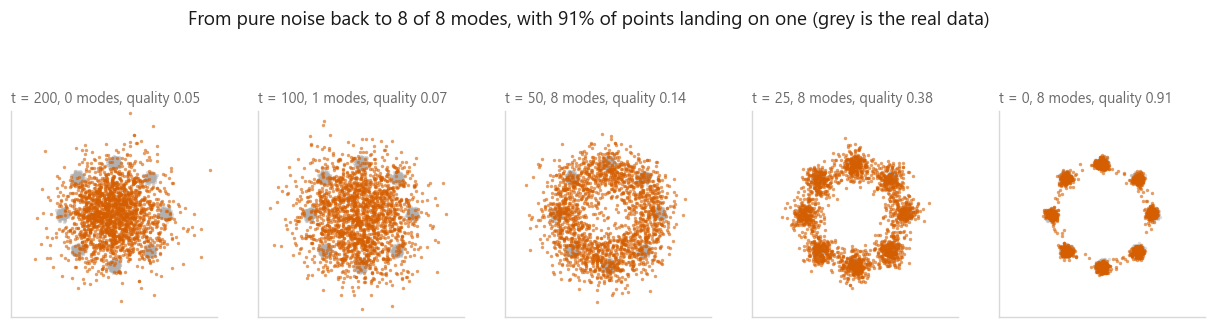

In [8]:
REVERSE_SHOW = [T // 2, T // 4, T // 8, 0]
final_cloud, snapshots = sample_ddpm(point_models[SEEDS[0]], N_EVAL, seed=SEED,
                                     record=tuple(REVERSE_SHOW))

fig, axes = plt.subplots(1, len(snapshots), figsize=(14.0, 3.4))
for ax, t in zip(axes, sorted(snapshots, reverse=True)):
    points = snapshots[t]
    stats = mode_stats(points.astype(np.float32))
    ax.scatter(real_cloud[:, 0], real_cloud[:, 1], s=5, linewidths=0,
               color=style.NEUTRAL, alpha=0.4)
    ax.scatter(points[:, 0], points[:, 1], s=5, linewidths=0,
               color=style.HIGHLIGHT, alpha=0.6)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t}, {stats['covered']} modes, quality {stats['quality']:.2f}",
                 fontsize=9.5, color=style.MUTED, loc="left")

final_stats = mode_stats(final_cloud)
fig.suptitle(f"From pure noise back to {final_stats['covered']} of {N_MODES} modes, "
             f"with {final_stats['quality']:.0%} of points landing on one "
             f"(grey is the real data)",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-reverse-sampling.png")

### Does the loss track sample quality

[10-03](../03-generative-adversarial-networks/) found the GAN's generator loss
told you nothing about coverage: the run that never reached the ring had the
lower loss. Diffusion has a fixed regression target, so the loss ought to behave.
Ought to is not measured, so here is the measurement, taken at checkpoints during
the first training run.

In [9]:
progress = point_histories[SEEDS[0]]
print(progress.to_string(index=False, float_format="{:.4f}".format))

if progress["quality"].std() > 1e-9:
    correlation = float(np.corrcoef(progress["loss"], progress["quality"])[0, 1])
    print(f"\ncorrelation between training loss and sample quality across "
          f"{len(progress)} checkpoints: {correlation:+.3f}")
    print("A negative correlation means a falling loss came with better samples.")
else:
    correlation = float("nan")
    print("\nsample quality never varied across the checkpoints, so a correlation "
          "is undefined here")

 step   loss  covered  quality
  500 0.4593        8   0.3330
 1000 0.3588        8   0.7530
 1500 0.3341        8   0.7810
 2000 0.3257        8   0.8260
 2500 0.3260        8   0.8380
 3000 0.3238        8   0.8450
 3500 0.3239        8   0.8430
 4000 0.3224        8   0.8600

correlation between training loss and sample quality across 8 checkpoints: -0.994
A negative correlation means a falling loss came with better samples.


## 4. Quality against the number of denoising steps

Sampling cost is one network pass per step, so the number of steps is a direct
purchase of compute. The DDIM sampler above takes an evenly spaced subsequence of
the chain, which lets the same trained model be run at any budget without
retraining.

In [10]:
STEP_BUDGETS = [2, 3, 5, 10, 20, 50, 100, 200]

rows = []
for budget in STEP_BUDGETS:
    started = time.perf_counter()
    cloud = sample_ddim(point_models[SEEDS[0]], N_EVAL, budget, seed=SEED)
    elapsed = time.perf_counter() - started
    stats = mode_stats(cloud)
    rows.append({"denoising steps": budget, "covered": stats["covered"],
                 "quality": stats["quality"], "imbalance": imbalance(stats["counts"]),
                 "seconds for 2,000 samples": elapsed})

steps_table = pd.DataFrame(rows)
print(steps_table.to_string(index=False, float_format="{:.4f}".format))

good = steps_table[steps_table["quality"] >= 0.95 * steps_table["quality"].max()]
cheapest = int(good["denoising steps"].min())
print(f"\nbest quality {steps_table['quality'].max():.3f} at "
      f"{int(steps_table.loc[steps_table['quality'].idxmax(), 'denoising steps'])} steps")
print(f"within five per cent of that already at {cheapest} steps, "
      f"which costs {float(good.loc[good['denoising steps'] == cheapest, 'seconds for 2,000 samples'].iloc[0]):.3f} s "
      f"against {float(steps_table['seconds for 2,000 samples'].max()):.3f} s for the full chain")

 denoising steps  covered  quality  imbalance  seconds for 2,000 samples
               2        1   0.0170     0.8162                     0.0051
               3        1   0.0265     0.6061                     0.0054
               5        8   0.4220     0.1013                     0.0088
              10        8   0.8005     0.0497                     0.0163
              20        8   0.8800     0.0432                     0.0364
              50        8   0.8925     0.0345                     0.0917
             100        8   0.8990     0.0334                     0.1604
             200        8   0.8980     0.0334                     0.3155

best quality 0.899 at 100 steps
within five per cent of that already at 20 steps, which costs 0.036 s against 0.315 s for the full chain


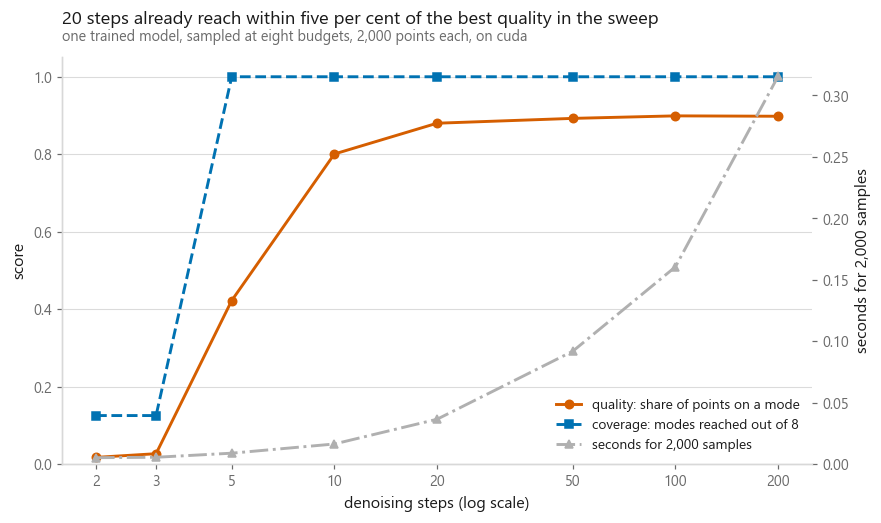

In [11]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(steps_table["denoising steps"], steps_table["quality"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], label="quality: share of points on a mode")
ax.plot(steps_table["denoising steps"], steps_table["covered"] / N_MODES,
        color=style.PALETTE[0], ls=style.DASHES[1], marker=style.MARKERS[1],
        label=f"coverage: modes reached out of {N_MODES}")
ax.set_xscale("log")
ax.minorticks_off()
ax.set_xticks(STEP_BUDGETS, [str(s) for s in STEP_BUDGETS])
ax.set_xlabel("denoising steps (log scale)")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)

twin = ax.twinx()
twin.plot(steps_table["denoising steps"], steps_table["seconds for 2,000 samples"],
          color=style.NEUTRAL, ls=style.DASHES[2], marker=style.MARKERS[2],
          label="seconds for 2,000 samples")
twin.set_ylabel("seconds for 2,000 samples")
twin.set_ylim(0, None)
twin.grid(False)

handles = ax.get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + twin.get_legend_handles_labels()[1]
ax.legend(handles, labels, loc="lower right", fontsize=9)

style.title(
    ax,
    f"{cheapest} steps already reach within five per cent of the best quality in "
    f"the sweep",
    f"one trained model, sampled at eight budgets, {N_EVAL:,} points each, on {device}")
style.save(fig, FIG / "fig-04-quality-against-steps.png")

The interesting part of that curve is the flat right-hand end. Once the chain is
long enough, more steps stop buying anything measurable and only cost time. Where
that knee sits depends on the schedule and the data, which is exactly why fast
samplers are a research area of their own: the model is not the bottleneck at
generation time, the length of the walk is.

## 5. Against the GAN, on the same ring

Now the comparison this notebook exists for. The generator and discriminator
below are the ones from [10-03](../03-generative-adversarial-networks/), trained
the same way with the non-saturating loss, on the same eight Gaussians, scored
with the same function. Three seeds each, because 10-03 found that a GAN's
outcome moves with the seed and a single run would not be evidence.

In [12]:
NOISE = 8


class Generator(nn.Module):
    """Copied from 10-03: noise in, a sample out."""

    def __init__(self, n_out=2, noise=NOISE, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, n_out),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Copied from 10-03: a binary classifier ending in a logit."""

    def __init__(self, n_in=2, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, width), nn.LeakyReLU(0.2),
            nn.Linear(width, width), nn.LeakyReLU(0.2),
            nn.Linear(width, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_gan(seed, steps=2500, lr=1e-3, batch=256):
    """The plain non-saturating GAN from 10-03, one update each per step."""
    torch.manual_seed(seed)
    data_rng = np.random.default_rng(seed)
    G, D = Generator().to(device), Discriminator().to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    started = time.perf_counter()
    for _ in range(steps):
        real = torch.from_numpy(sample_ring(batch, data_rng)).to(device)
        with torch.no_grad():
            fake = G(torch.randn(batch, NOISE, device=device))
        out_real, out_fake = D(real), D(fake)
        d_loss = (bce(out_real, torch.ones_like(out_real))
                  + bce(out_fake, torch.zeros_like(out_fake)))
        opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()

        out = D(G(torch.randn(batch, NOISE, device=device)))
        g_loss = bce(out, torch.ones_like(out))          # -log D(G(z))
        opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()

    with torch.no_grad():
        cloud = G(torch.randn(N_EVAL, NOISE, device=device)).cpu().numpy()
    return cloud, time.perf_counter() - started


comparison_rows = []
gan_clouds, diffusion_clouds = {}, {}

for seed in SEEDS:
    cloud, seconds = train_gan(seed)
    gan_clouds[seed] = cloud
    stats = mode_stats(cloud)
    comparison_rows.append({"family": "GAN", "seed": seed, "covered": stats["covered"],
                            "quality": stats["quality"],
                            "imbalance": imbalance(stats["counts"]),
                            "train seconds": seconds})

for seed in SEEDS:
    cloud = sample_ddpm(point_models[seed], N_EVAL, seed=seed)[0]
    diffusion_clouds[seed] = cloud
    stats = mode_stats(cloud)
    comparison_rows.append({"family": "diffusion", "seed": seed, "covered": stats["covered"],
                            "quality": stats["quality"],
                            "imbalance": imbalance(stats["counts"]),
                            "train seconds": point_seconds[seed]})

comparison = pd.DataFrame(comparison_rows)
print(comparison.to_string(index=False, float_format="{:.4f}".format))

summary = comparison.groupby("family")[["covered", "quality", "imbalance"]].mean()
summary.loc["real data"] = [real_stats["covered"], real_stats["quality"],
                            imbalance(real_stats["counts"])]
print()
print(summary.to_string(float_format="{:.4f}".format))

gan_cover = comparison[comparison["family"] == "GAN"]["covered"]
diff_cover = comparison[comparison["family"] == "diffusion"]["covered"]
gan_imbalance = comparison[comparison["family"] == "GAN"]["imbalance"].mean()
diff_imbalance = comparison[comparison["family"] == "diffusion"]["imbalance"].mean()

if diff_cover.min() > gan_cover.min():
    verdict = ("diffusion covered more modes than the GAN at its worst seed, which is "
               "the claim as usually stated")
elif diff_cover.min() == gan_cover.min() == N_MODES:
    verdict = (f"both families reached all {N_MODES} modes at every seed, so coverage "
               f"does not separate them on this ring")
else:
    verdict = ("the GAN matched or beat diffusion on coverage here, which is not what "
               "the usual claim predicts")

print(f"\nverdict on coverage: {verdict}")
print(f"mean imbalance: GAN {gan_imbalance:.4f}, diffusion {diff_imbalance:.4f}, "
      f"real data {imbalance(real_stats['counts']):.4f}")
if diff_imbalance < gan_imbalance:
    print("On the finer measure, diffusion spread its mass more evenly across the "
          "modes than the GAN did.")
else:
    print("On the finer measure, the GAN spread its mass at least as evenly as "
          "diffusion did, which I did not expect.")

   family  seed  covered  quality  imbalance  train seconds
      GAN     0        8   0.9070     0.0402        31.4392
      GAN     1        8   0.9055     0.0555        28.8093
      GAN     2        8   0.8895     0.0228        23.4455
diffusion     0        8   0.9140     0.0380        27.2144
diffusion     1        8   0.9445     0.0564        26.2959
diffusion     2        8   0.9420     0.0563        23.8260

           covered  quality  imbalance
family                                
GAN         8.0000   0.9007     0.0395
diffusion   8.0000   0.9335     0.0502
real data   8.0000   0.9935     0.0222

verdict on coverage: both families reached all 8 modes at every seed, so coverage does not separate them on this ring
mean imbalance: GAN 0.0395, diffusion 0.0502, real data 0.0222
On the finer measure, the GAN spread its mass at least as evenly as diffusion did, which I did not expect.


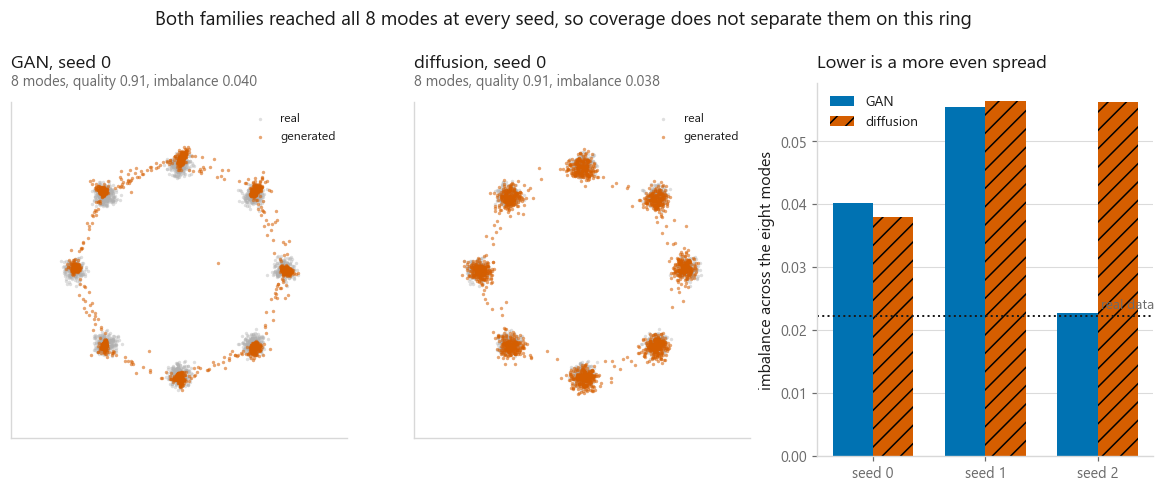

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.4))

for ax, (label, cloud) in zip(axes[:2], [("GAN", gan_clouds[SEEDS[0]]),
                                         ("diffusion", diffusion_clouds[SEEDS[0]])]):
    stats = mode_stats(cloud.astype(np.float32))
    ax.scatter(real_cloud[:, 0], real_cloud[:, 1], s=5, linewidths=0,
               color=style.NEUTRAL, alpha=0.4, label="real")
    ax.scatter(cloud[:, 0], cloud[:, 1], s=5, linewidths=0,
               color=style.HIGHLIGHT, alpha=0.55, label="generated")
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    style.title(ax, f"{label}, seed {SEEDS[0]}",
                f"{stats['covered']} modes, quality {stats['quality']:.2f}, "
                f"imbalance {imbalance(stats['counts']):.3f}")

positions = np.arange(len(SEEDS))
width = 0.36
axes[2].bar(positions - width / 2, [imbalance(mode_stats(gan_clouds[s])["counts"]) for s in SEEDS],
            width=width, color=style.PALETTE[0], label="GAN")
axes[2].bar(positions + width / 2,
            [imbalance(mode_stats(diffusion_clouds[s])["counts"]) for s in SEEDS],
            width=width, color=style.HIGHLIGHT, label="diffusion")
for bar in axes[2].patches[len(SEEDS):]:
    bar.set_hatch("//")
axes[2].axhline(imbalance(real_stats["counts"]), color=style.INK, ls=":", lw=1.3)
axes[2].annotate("real data", xy=(len(SEEDS) - 0.5, imbalance(real_stats["counts"])),
                 xytext=(0, 5), textcoords="offset points", ha="right",
                 fontsize=9, color=style.MUTED)
axes[2].set_xticks(positions, [f"seed {s}" for s in SEEDS])
axes[2].set_ylabel("imbalance across the eight modes")
axes[2].set_ylim(0, None)
axes[2].legend(loc="upper left", fontsize=9)
style.title(axes[2], "Lower is a more even spread")

fig.suptitle(verdict[0].upper() + verdict[1:], x=0.5, y=1.03,
             fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-diffusion-against-gan.png")

Two caveats before anyone quotes that. The ring is a two-dimensional problem
with eight well-separated modes and both models train on it in seconds, so it is
a place to see mechanisms rather than a place to rank methods. And the sampling
budgets are wildly different: the GAN produces a point in one forward pass while
the diffusion model took the full chain. On equal wall-clock the comparison would
read differently, and the step sweep in section 4 is where you would go to
construct it.

## 6. The same thing on images

Everything above transfers with two changes: the denoiser becomes convolutional,
and the schedule is applied to pixels instead of coordinates. Expectations first,
because they belong before the pictures rather than after them.

This is a small U-Net given a few minutes on a laptop, on twelve thousand
images. It produces garment silhouettes with soft edges and visible noise. It
will not produce anything you would mistake for a photograph, and published
image diffusion models use compute orders of magnitude larger than this budget.
The samples shown are the first ones drawn from noise vectors fixed before
training, and the whole grid is shown. Nothing is selected.

In [14]:
N_IMAGES = 12_000
IMAGE_EPOCHS = 5
IMAGE_BATCH = 128


def image_subsample(n_rows, seed=SEED):
    """The same subsample as 10-01 to 10-03, rescaled to [-1, 1] to match the noise."""
    dataset = datasets.fashion_mnist(train=True)
    generator = torch.Generator().manual_seed(seed)
    picks = torch.randperm(len(dataset), generator=generator)[:n_rows]
    images = dataset.data[picks].unsqueeze(1).float().div_(255.0)
    return images * 2.0 - 1.0


x_images = image_subsample(N_IMAGES)
print(f"training images {tuple(x_images.shape)}, "
      f"range {x_images.min():.1f} to {x_images.max():.1f}")


class Block(nn.Module):
    """Two convolutions with the step embedding added in between, as a per-channel bias."""

    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time = nn.Linear(time_dim, out_ch)

    def forward(self, x, embedding):
        h = F.silu(self.norm1(self.conv1(x))) + self.time(embedding)[:, :, None, None]
        return F.silu(self.norm2(self.conv2(h)))


class ImageDenoiser(nn.Module):
    """A small U-Net, the same shape as 08-06's, told how noisy its input is."""

    def __init__(self, c=16, time_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.embed = nn.Sequential(nn.Linear(time_dim, time_dim), nn.SiLU(),
                                   nn.Linear(time_dim, time_dim))
        self.enc1 = Block(1, c, time_dim)
        self.enc2 = Block(c, 2 * c, time_dim)
        self.middle = Block(2 * c, 2 * c, time_dim)
        self.up2 = nn.ConvTranspose2d(2 * c, 2 * c, 2, stride=2)
        self.dec2 = Block(4 * c, c, time_dim)
        self.up1 = nn.ConvTranspose2d(c, c, 2, stride=2)
        self.dec1 = Block(2 * c, c, time_dim)
        self.head = nn.Conv2d(c, 1, 1)

    def forward(self, x, t):
        e = self.embed(timestep_embedding(t, self.time_dim))
        a = self.enc1(x, e)                                  # 28
        b = self.enc2(F.max_pool2d(a, 2), e)                 # 14
        m = self.middle(F.max_pool2d(b, 2), e)               # 7
        d = self.dec2(torch.cat([self.up2(m), b], dim=1), e)  # 14
        d = self.dec1(torch.cat([self.up1(d), a], dim=1), e)  # 28
        return self.head(d)


print(f"{sum(p.numel() for p in ImageDenoiser().parameters()):,} parameters in the "
      f"image denoiser")

training images (12000, 1, 28, 28), range -1.0 to 1.0
74,593 parameters in the image denoiser


In [15]:
torch.manual_seed(SEED)
image_model = ImageDenoiser().to(device)
optimiser = torch.optim.Adam(image_model.parameters(), lr=2e-3)

started = time.perf_counter()
image_history = []
for epoch in range(1, IMAGE_EPOCHS + 1):
    order = torch.randperm(len(x_images), generator=torch.Generator().manual_seed(epoch))
    running, seen = 0.0, 0
    for start in range(0, len(order), IMAGE_BATCH):
        x0 = x_images[order[start:start + IMAGE_BATCH]].to(device)
        t = torch.randint(0, T, (len(x0),), device=device)
        noise = torch.randn_like(x0)
        keep = alphas_bar_d[t].sqrt()[:, None, None, None]
        add = (1 - alphas_bar_d[t]).sqrt()[:, None, None, None]

        optimiser.zero_grad(set_to_none=True)
        loss = F.mse_loss(image_model(keep * x0 + add * noise, t), noise)
        loss.backward()
        optimiser.step()
        running += float(loss) * len(x0)
        seen += len(x0)
    image_history.append({"epoch": epoch, "loss": running / seen})
    print(f"epoch {epoch}: loss {running / seen:.4f}")

print(f"trained in {(time.perf_counter() - started) / 60:.1f} minutes on {device}")

epoch 1: loss 0.1991


epoch 2: loss 0.1047


epoch 3: loss 0.0932


epoch 4: loss 0.0887


epoch 5: loss 0.0837
trained in 0.2 minutes on cuda


In [16]:
@torch.no_grad()
def sample_images(model, n, seed=SEED, record=()):
    """The ancestral sampler again, unchanged except for the shape of x."""
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 1, 28, 28, generator=generator).to(device)
    snapshots = {T: x[0, 0].cpu().numpy()}

    for t in reversed(range(T)):
        index = torch.full((n,), t, device=device, dtype=torch.long)
        predicted = model(x, index)
        mean = (x - betas_d[t] / (1 - alphas_bar_d[t]).sqrt() * predicted) / alphas_d[t].sqrt()
        if t > 0:
            noise = torch.randn(x.shape, generator=generator).to(device)
            x = mean + betas_d[t].sqrt() * noise
        else:
            x = mean
        if t in record:
            snapshots[t] = x[0, 0].cpu().numpy()

    model.train()
    return x.cpu().numpy(), snapshots


TRAJECTORY = [int(round(v)) for v in np.linspace(T - 1, 0, 7)]
started = time.perf_counter()
samples, image_snapshots = sample_images(image_model, 8, record=tuple(TRAJECTORY))
print(f"eight samples in {time.perf_counter() - started:.0f} s, "
      f"{T} network passes each")
print(f"sample pixel range: {samples.min():.2f} to {samples.max():.2f}, "
      f"against {x_images.min():.2f} to {x_images.max():.2f} for the training data")

eight samples in 1 s, 200 network passes each
sample pixel range: -2.14 to 1.64, against -1.00 to 1.00 for the training data


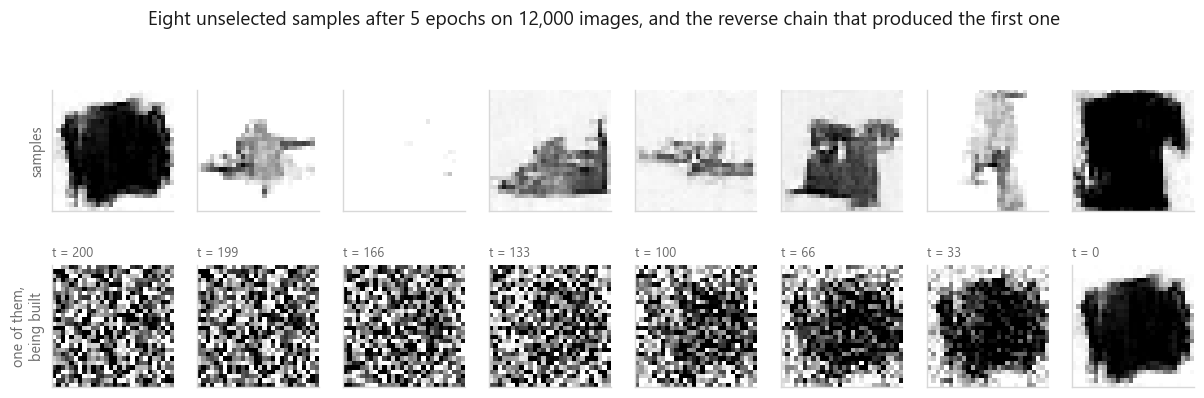

In [17]:
fig, axes = plt.subplots(2, 8, figsize=(13.4, 3.8))
for column in range(8):
    axes[0, column].imshow(np.clip(samples[column, 0], -1, 1), cmap="gray_r",
                           vmin=-1, vmax=1)
    axes[0, column].set_xticks([]); axes[0, column].set_yticks([])
    axes[0, column].grid(False)

for column, t in enumerate(sorted(image_snapshots, reverse=True)[:8]):
    axes[1, column].imshow(np.clip(image_snapshots[t], -1, 1), cmap="gray_r",
                           vmin=-1, vmax=1)
    axes[1, column].set_xticks([]); axes[1, column].set_yticks([])
    axes[1, column].grid(False)
    axes[1, column].set_title(f"t = {t}", fontsize=8.5, color=style.MUTED, loc="left")

axes[0, 0].set_ylabel("samples", fontsize=9.5, color=style.MUTED)
axes[1, 0].set_ylabel("one of them,\nbeing built", fontsize=9.5, color=style.MUTED)

fig.suptitle(f"Eight unselected samples after {IMAGE_EPOCHS} epochs on "
             f"{N_IMAGES:,} images, and the reverse chain that produced the first one",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-06-fashion-samples.png")

In [18]:
print(f"whole notebook: {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} minutes on {device}")

whole notebook: 3.1 minutes on cuda


## Cheat sheet

| | |
|---|---|
| **Forward** | `x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps`. Fixed, parameter-free, jumps to any t in one line |
| **What the net predicts** | The noise `eps`, from the noisy sample and the step index. Mean squared error, nothing adversarial |
| **Reverse step** | Subtract the predicted noise, rescale by `1/sqrt(alpha_t)`, add `sigma_t z` except on the last step |
| **Time conditioning** | Sinusoidal embedding of the step index, fed into every block. A raw integer is not enough |
| **Schedule** | Linear in beta is not linear in what survives. Check `sqrt(alpha_bar_T)` is near zero or the sampler starts from the wrong distribution |
| **Sampling cost** | One forward pass per step. This is the method's weakness and the reason DDIM and its descendants exist |
| **Fewer steps** | Take a subsequence of the chain deterministically. Section 4 has the quality against the budget |
| **Against GANs** | Stable training, honest loss, expensive sampling. The GAN is one pass and a fight |
| **Watch out** | Data has to be scaled to match the terminal Gaussian, hence the rescale to [-1, 1] on images |

## What to remember

1. The forward process is fixed arithmetic. Only the reverse is learned, and what
   it learns is a noise predictor trained with mean squared error.
2. The closed form for `q(x_t | x_0)` is what makes training cheap: any step is
   one draw away, so no chain is ever simulated during training.
3. The loss is a real progress signal, unlike the GAN's. Section 3 prints the
   correlation between loss and sample quality across training checkpoints.
4. Sampling cost is linear in the number of steps and quality flattens out well
   before the full chain. Section 4 prints where the knee was on this problem.
5. On the ring from 10-03, with the same coverage metric, the printed verdict in
   section 5 says whether diffusion beat the GAN. Coverage saturates on an easy
   problem, which is why the imbalance measure is there.
6. The comparison is not on equal compute. The GAN samples in one pass and the
   diffusion model took the whole chain.
7. The image model is the same code with a convolutional denoiser. Nothing about
   the method changed between the ring and the images except the shape of the
   network and the shape of the noise.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-01 The reinforcement learning setup](../../11-reinforcement-learning/01-the-rl-setup/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#DiffusionModels` `#DDPM` `#GenerativeAI` `#PyTorch`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`